# 02 — Notebook Underfitting
## Kernel SVM volontairement sous-ajusté (high bias)

**Objectif :** construire délibérément un modèle Kernel SVM en situation d'**underfitting**, expliquer pourquoi il l'est, et interpréter ses métriques. Ce notebook sera comparé au notebook `03_Overfitting.ipynb` en Phase 5 pour sélectionner et optimiser le meilleur des deux.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from src.data import load_dataset, get_modeling_sample, get_X_y
from src.preprocessing import build_preprocessor, split_data
from src.config import REPORTS_DIR, RANDOM_STATE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
REPORTS_DIR.mkdir(exist_ok=True)

## Rappel — Phase 2 : Prétraitement

Le pipeline de prétraitement (`src/preprocessing.py`) est **partagé par tous les notebooks de modélisation** (underfitting, overfitting, optimisation) afin que la comparaison entre modèles porte uniquement sur les hyperparamètres, pas sur des différences de préparation des données.

Rappel des décisions prises (justifiées en détail lors de l'analyse exploratoire menée en amont) :
- **Échantillon stratifié de 12 000 lignes** (`src/config.SAMPLE_SIZE`) : le Kernel SVM (libsvm) a une complexité ~O(n²·⁵), ce qui rend l'entraînement sur 100 000 lignes impraticable (~15-20 min par fit, GridSearchCV en heures). Le sous-échantillonnage stratifié préserve le ratio de déséquilibre (8.94:1) observé sur le jeu de données complet.
- **`StandardScaler`** sur les variables numériques : indispensable pour un modèle à noyau, sensible à l'échelle des features (le noyau RBF repose sur une distance euclidienne).
- **`OneHotEncoder`** sur `Gender` (binaire, `drop="if_binary"`) et `Department` (5 catégories, toutes conservées).
- **Split stratifié 80/20** : préserve le ratio de classes dans train et test.
- **`Student_ID` exclu** : identifiant sans valeur prédictive.


In [2]:
df = load_dataset()
sample = get_modeling_sample(df)
X, y = get_X_y(sample)
X_train, X_test, y_train, y_test = split_data(X, y)

preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f"Train: {X_train_t.shape}, Test: {X_test_t.shape}")
print(f"Ratio Depression=True — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Train: (9600, 13), Test: (2400, 13)
Ratio Depression=True — train: 0.101, test: 0.100


## Construction volontaire d'un modèle en underfitting

Pour un **Kernel SVM à noyau RBF**, deux hyperparamètres contrôlent directement la complexité du modèle :

- **`C`** (paramètre de régularisation) : un `C` **très faible** pénalise très peu les erreurs de classification sur le train → le modèle privilégie une marge large et simple plutôt que de coller aux données. C'est un facteur de **haut biais**.
- **`gamma`** (portée de l'influence de chaque point pour le noyau RBF) : un `gamma` **très faible** signifie que chaque point d'entraînement influence une zone très large de l'espace → la fonction de décision devient extrêmement lisse, presque constante, incapable de capturer la moindre structure locale.

En combinant un `C` et un `gamma` **extrêmement faibles** (`C=0.001`, `gamma=0.001`), on force le modèle à être trop simple pour apprendre quoi que ce soit des données : c'est la définition même de l'underfitting.


In [3]:
underfit_model = SVC(kernel="rbf", C=0.001, gamma=0.001, random_state=RANDOM_STATE)
underfit_model.fit(X_train_t, y_train)

y_train_pred = underfit_model.predict(X_train_t)
y_test_pred = underfit_model.predict(X_test_t)

print(f"Nombre de vecteurs de support : {underfit_model.n_support_.sum()} / {len(y_train)} ({underfit_model.n_support_.sum()/len(y_train)*100:.1f}%)")
print(f"Prédictions train — classe prédite majoritaire uniquement ? {set(y_train_pred) == {0}}")
print(f"Prédictions test  — classe prédite majoritaire uniquement ? {set(y_test_pred) == {0}}")

Nombre de vecteurs de support : 1932 / 9600 (20.1%)
Prédictions train — classe prédite majoritaire uniquement ? True
Prédictions test  — classe prédite majoritaire uniquement ? True


## Métriques

In [4]:
def compute_metrics(y_true, y_pred, label):
    return {
        "set": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

underfit_metrics = pd.DataFrame([
    compute_metrics(y_train, y_train_pred, "train"),
    compute_metrics(y_test, y_test_pred, "test"),
])
underfit_metrics

,set,accuracy,precision,recall,f1
0,train,0.899375,0.0,0.0,0.0
1,test,0.899583,0.0,0.0,0.0


In [5]:
print("=== Classification report — TEST ===")
print(classification_report(y_test, y_test_pred, target_names=["Not Depressed", "Depressed"], zero_division=0))

=== Classification report — TEST ===
               precision    recall  f1-score   support

Not Depressed       0.90      1.00      0.95      2159
    Depressed       0.00      0.00      0.00       241

     accuracy                           0.90      2400
    macro avg       0.45      0.50      0.47      2400
 weighted avg       0.81      0.90      0.85      2400



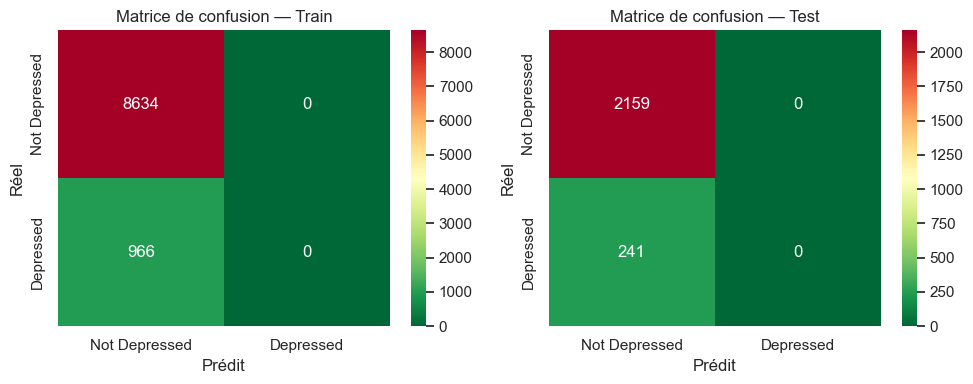

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_train, y_train_pred, "Train"), (y_test, y_test_pred, "Test")],
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn_r", ax=ax,
                xticklabels=["Not Depressed", "Depressed"],
                yticklabels=["Not Depressed", "Depressed"])
    ax.set_title(f"Matrice de confusion — {title}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "underfit_confusion_matrices.png", bbox_inches="tight")
plt.show()

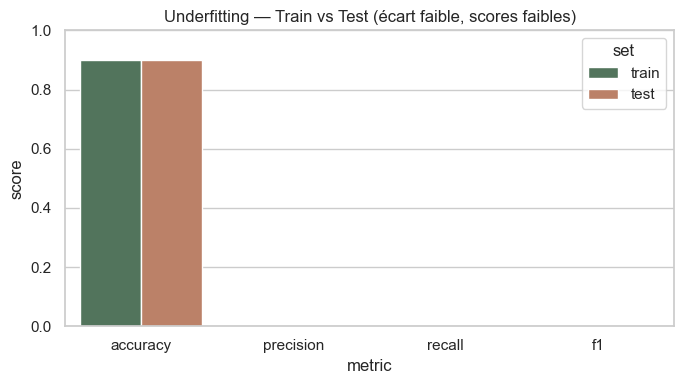

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics_plot = underfit_metrics.melt(id_vars="set", var_name="metric", value_name="score")
sns.barplot(data=metrics_plot, x="metric", y="score", hue="set", ax=ax, palette=["#4C7A5A", "#C97B5A"])
ax.set_ylim(0, 1)
ax.set_title("Underfitting — Train vs Test (écart faible, scores faibles)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "underfit_train_vs_test.png", bbox_inches="tight")
plt.show()

## Interprétation

Les résultats confirment le diagnostic d'**underfitting** :

- **Accuracy train ≈ test (~0.90)** : à première vue, ce chiffre semble bon, mais il correspond exactement à la proportion de la classe majoritaire (`Depression=False` = 89.9 %). Le modèle n'a rien appris — il prédit la classe majoritaire pour (quasiment) toutes les observations, qu'il s'agisse du train ou du test.
- **F1 / Recall / Precision ≈ 0 sur les deux ensembles** : la classe minoritaire (`Depression=True`), pourtant celle qui nous intéresse cliniquement, n'est jamais détectée.
- **Écart train/test quasi nul** : c'est la signature caractéristique de l'underfitting (haut biais, faible variance) — contrairement à l'overfitting, il n'y a pas de fossé entre les performances train et test, simplement parce que le modèle n'a pas la capacité de s'ajuster ni aux données d'entraînement, ni à de nouvelles données.

Ce modèle est **inutilisable en pratique** malgré une accuracy trompeusement élevée — d'où l'importance de ne jamais évaluer un modèle sur données déséquilibrées avec la seule accuracy. Ce constat sera comparé au notebook `03_Overfitting.ipynb`.


In [8]:
underfit_summary = {
    "model": "SVC(kernel='rbf', C=0.001, gamma=0.001)",
    "n_support_vectors": int(underfit_model.n_support_.sum()),
    "train": compute_metrics(y_train, y_train_pred, "train"),
    "test": compute_metrics(y_test, y_test_pred, "test"),
}
with open(REPORTS_DIR / "underfit_metrics.json", "w") as f:
    json.dump(underfit_summary, f, indent=2, default=float)

print("Sauvegardé : reports/underfit_metrics.json")
underfit_summary

Sauvegardé : reports/underfit_metrics.json


{'model': "SVC(kernel='rbf', C=0.001, gamma=0.001)",
 'n_support_vectors': 1932,
 'train': {'set': 'train',
  'accuracy': 0.899375,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 'test': {'set': 'test',
  'accuracy': 0.8995833333333333,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0}}